In [26]:
from pathlib import Path
import pickle
import pandas as pd
import numpy as np

from hydrax.utils.files import get_data_path


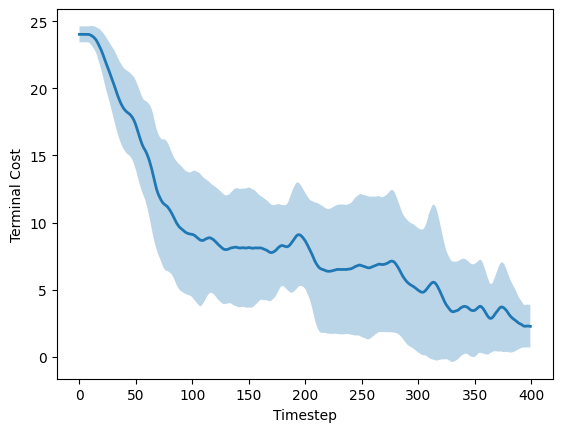

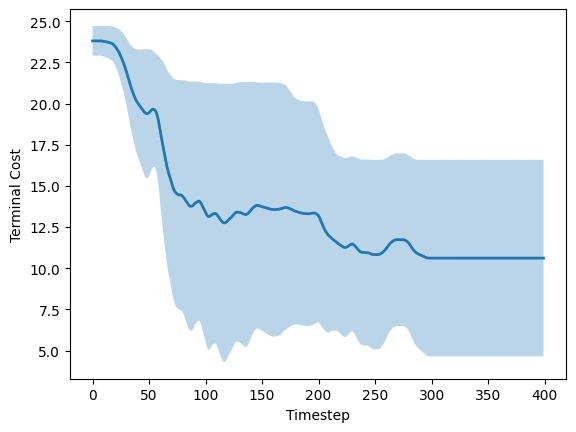

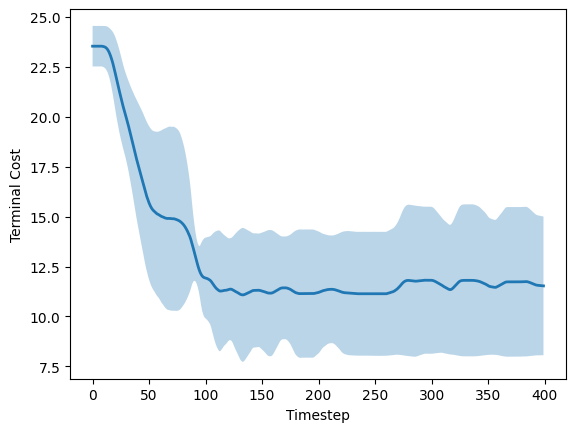

In [45]:
from scipy.ndimage import uniform_filter1d  # Or use np.convolve
import matplotlib.pyplot as plt




# seeds = [10, 11, 12, 13, 14]
seeds = [20, 21, 22, 23, 24, 25]

for algo in ["MTP", "MPPI", "CEM"]:
    costs = np.empty((400, len(seeds)))
    for seed in seeds:
        path = get_data_path() / "sim-real-free" / f"fr3_pusht_{algo}_seed{seed}.pkl"
        with open(path, "rb") as f:
            data = pickle.load(f)

            costs[:, seeds.index(seed)] = np.array([d["terminal_error"]for d in data])[:400] 
    mean = np.mean(costs, axis=1)
    std = np.std(costs, axis=1)

    window = 8  # Adjust for smoothness (odd number recommended)

    mean_smooth = uniform_filter1d(mean, size=window)
    std_smooth = uniform_filter1d(std, size=window)

    plt.plot(mean_smooth, linewidth=2)
    plt.fill_between(range(len(mean_smooth)), 
                    mean_smooth - std_smooth, 
                    mean_smooth + std_smooth, alpha=0.3)
    plt.xlabel("Timestep")
    plt.ylabel("Terminal Cost")
    plt.show()
    